#Phase 5: SHAP Explainability Using Boosting Model

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path
import joblib

import shap
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

In [3]:
print(np.__version__)

2.3.5


In [8]:
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"

df = pd.read_csv(PROCESSED_DIR / "model_training_table.csv")

target_col = "failure_next_30_days"

X = df.drop(columns=["vehicle_id", target_col])
y = df[target_col]

vehicle_ids = df["vehicle_id"]

In [5]:
target_col = "failure_next_30_days"

X = df[feature_columns]
y = df[target_col]

print("X shape:", X.shape)
print("Predictions shape:", predictions.shape)

X shape: (3000, 65)
Predictions shape: (600, 4)


In [10]:
from sklearn.model_selection import train_test_split

In [13]:
from xgboost import XGBClassifier

In [14]:
xgb_explain_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_explain_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
X_train, X_test, y_train, y_test, vehicle_train, vehicle_test = train_test_split(
    X,
    y,
    vehicle_ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
joblib.dump(xgb_explain_model, MODEL_DIR / "xgb_explainability_model.pkl")

print("Saved XGBoost explainability model.")

Saved XGBoost explainability model.


In [16]:
y_proba = xgb_explain_model.predict_proba(X_test)[:, 1]

prediction_df = pd.DataFrame({
    "vehicle_id": vehicle_test.values,
    "actual_failure": y_test.values,
    "failure_probability": y_proba
})

prediction_df["risk_level"] = pd.cut(
    prediction_df["failure_probability"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"]
)

prediction_df = prediction_df.sort_values("failure_probability", ascending=False)

prediction_df.head(10)

,vehicle_id,actual_failure,failure_probability,risk_level
542,V02415,1,0.991954,High
285,V01807,1,0.986772,High
94,V02213,1,0.984313,High
254,V02985,1,0.983147,High
48,V02944,1,0.981330,High
237,V02193,1,0.980730,High
127,V02171,1,0.980329,High
158,V00989,1,0.980099,High
540,V00540,1,0.978793,High
182,V01054,1,0.978281,High


In [17]:
explainer = shap.TreeExplainer(xgb_explain_model)

shap_values = explainer.shap_values(X_test)

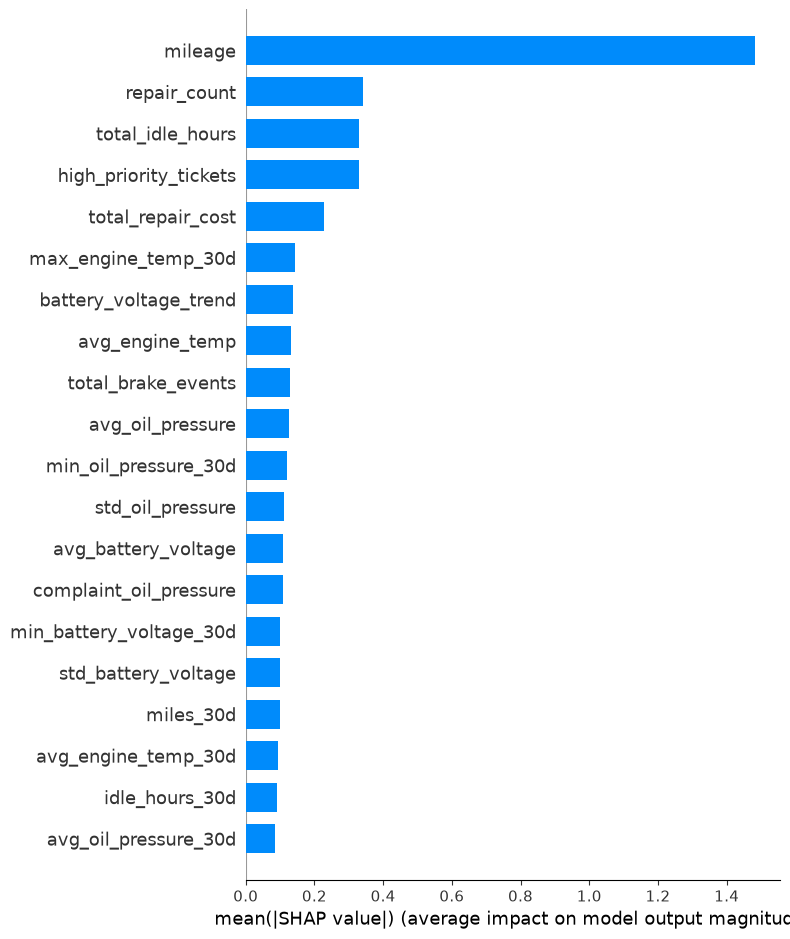

In [18]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=20
)

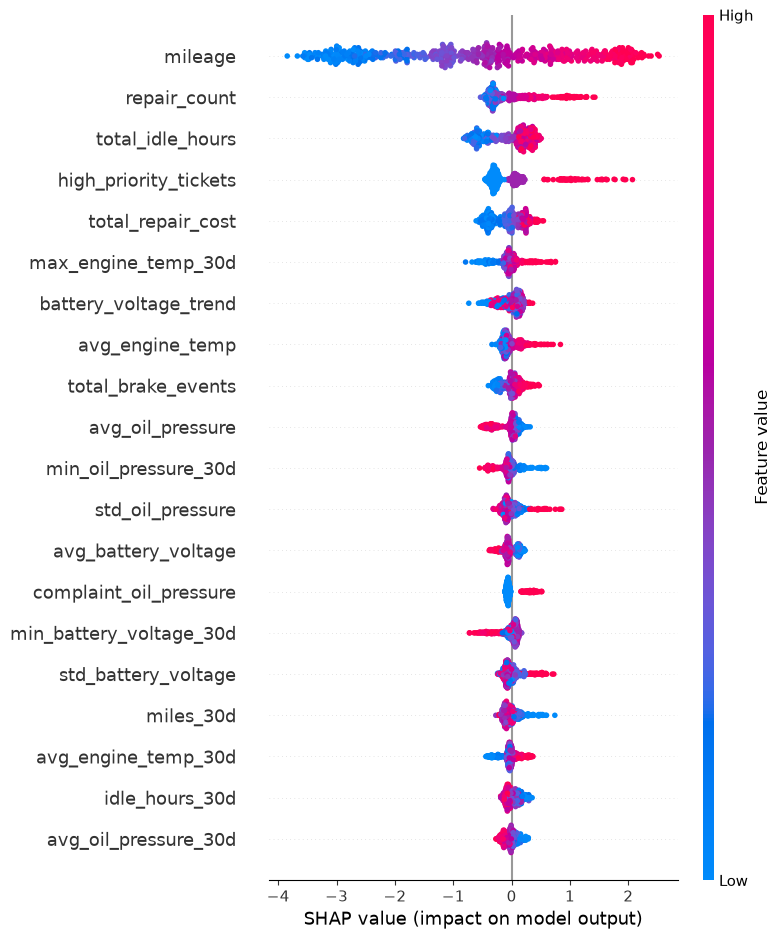

In [19]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

In [20]:
high_risk_vehicle_id = prediction_df.iloc[0]["vehicle_id"]

high_risk_index = list(vehicle_test.values).index(high_risk_vehicle_id)

print("High-risk vehicle:", high_risk_vehicle_id)
print("Failure probability:", prediction_df.iloc[0]["failure_probability"])

High-risk vehicle: V02415
Failure probability: 0.9919538


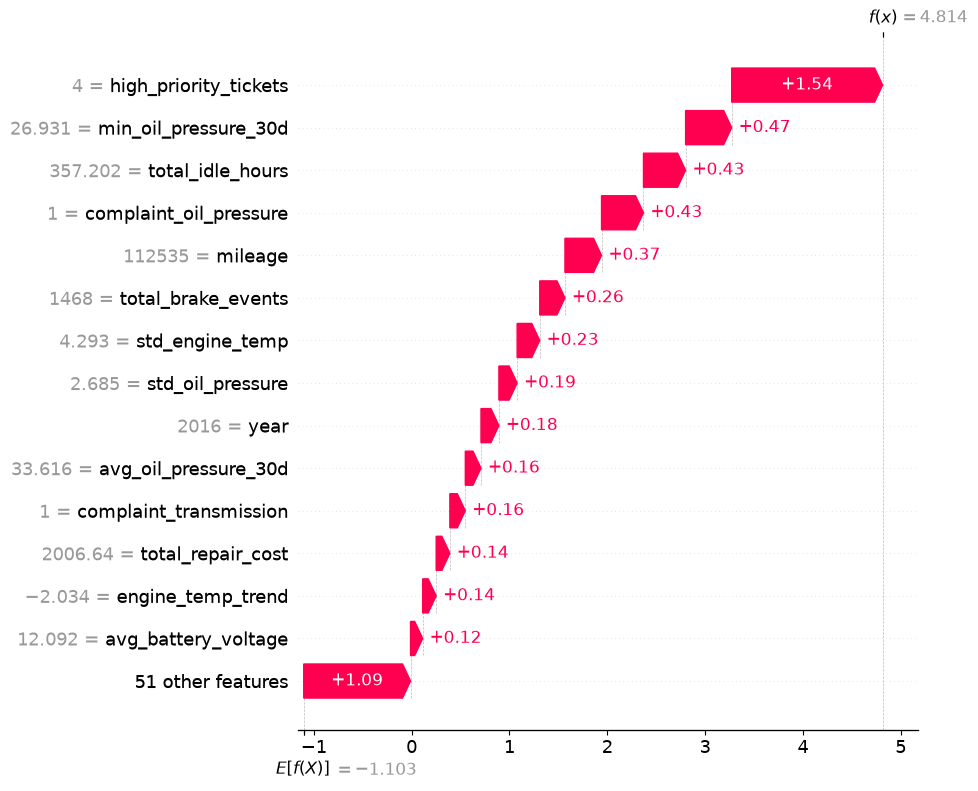

In [21]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_index],
        feature_names=X_test.columns
    ),
    max_display=15
)

In [22]:
def explain_vehicle_risk(vehicle_id, X_test, vehicle_test, shap_values, prediction_df, top_n=5):
    idx = list(vehicle_test.values).index(vehicle_id)

    row = X_test.iloc[idx]
    vehicle_shap = shap_values[idx]

    explanation = pd.DataFrame({
        "feature": X_test.columns,
        "feature_value": row.values,
        "shap_impact": vehicle_shap
    })

    explanation["abs_impact"] = explanation["shap_impact"].abs()

    top_features = explanation.sort_values(
        "abs_impact",
        ascending=False
    ).head(top_n)

    risk_score = prediction_df.loc[
        prediction_df["vehicle_id"] == vehicle_id,
        "failure_probability"
    ].iloc[0]

    return risk_score, top_features

In [23]:
vehicle_id = prediction_df.iloc[0]["vehicle_id"]

risk_score, top_features = explain_vehicle_risk(
    vehicle_id,
    X_test,
    vehicle_test,
    shap_values,
    prediction_df
)

print("Vehicle:", vehicle_id)
print("Risk score:", round(risk_score, 3))

top_features

Vehicle: V02415
Risk score: 0.992


,feature,feature_value,shap_impact,abs_impact
44,high_priority_tickets,4.0,1.542942,1.542942
24,min_oil_pressure_30d,26.931036,0.471197,0.471197
17,total_idle_hours,357.201643,0.430535,0.430535
51,complaint_oil_pressure,1.0,0.428826,0.428826
1,mileage,112535,0.373901,0.373901


In [24]:
def generate_maintenance_recommendation(top_features):
    features = top_features["feature"].tolist()

    recommendations = []

    if any("engine_temp" in f for f in features):
        recommendations.append("Inspect cooling system, coolant level, radiator, and thermostat.")

    if any("oil_pressure" in f for f in features):
        recommendations.append("Check oil level, oil pump, oil filter, and pressure sensor.")

    if any("battery_voltage" in f for f in features):
        recommendations.append("Test battery health, alternator output, and terminal connections.")

    if any("brake" in f for f in features):
        recommendations.append("Inspect brake pads, rotors, brake fluid, and driver braking behavior.")

    if any("repair" in f for f in features):
        recommendations.append("Review recent repair history for recurring unresolved issues.")

    if any("ticket" in f or "complaint" in f for f in features):
        recommendations.append("Review driver/customer complaints and prioritize service follow-up.")

    if not recommendations:
        recommendations.append("Schedule standard preventive maintenance inspection.")

    return recommendations

In [25]:
vehicle_id = prediction_df.iloc[0]["vehicle_id"]

risk_score, top_features = explain_vehicle_risk(
    vehicle_id,
    X_test,
    vehicle_test,
    shap_values,
    prediction_df
)

recommendations = generate_maintenance_recommendation(top_features)

print(f"Vehicle: {vehicle_id}")
print(f"Failure Probability: {risk_score:.2%}")
print("\nTop Risk Drivers:")
display(top_features[["feature", "feature_value", "shap_impact"]])

print("\nRecommended Actions:")
for rec in recommendations:
    print("-", rec)

Vehicle: V02415
Failure Probability: 99.20%

Top Risk Drivers:


,feature,feature_value,shap_impact
44,high_priority_tickets,4.0,1.542942
24,min_oil_pressure_30d,26.931036,0.471197
17,total_idle_hours,357.201643,0.430535
51,complaint_oil_pressure,1.0,0.428826
1,mileage,112535,0.373901



Recommended Actions:
- Check oil level, oil pump, oil filter, and pressure sensor.
- Review driver/customer complaints and prioritize service follow-up.


In [26]:
explanation_records = []

for vehicle_id in prediction_df["vehicle_id"].head(100):
    risk_score, top_features = explain_vehicle_risk(
        vehicle_id,
        X_test,
        vehicle_test,
        shap_values,
        prediction_df,
        top_n=5
    )

    recommendations = generate_maintenance_recommendation(top_features)

    explanation_records.append({
        "vehicle_id": vehicle_id,
        "failure_probability": risk_score,
        "top_features": top_features["feature"].tolist(),
        "top_feature_values": top_features["feature_value"].tolist(),
        "top_shap_impacts": top_features["shap_impact"].tolist(),
        "recommendations": recommendations
    })

explanations_df = pd.DataFrame(explanation_records)

explanations_df.to_csv(
    PROCESSED_DIR / "vehicle_risk_explanations.csv",
    index=False
)

print("Saved vehicle explanations.")

Saved vehicle explanations.


I trained a boosting-based explainability model using XGBoost and SHAP to explain vehicle-level failure predictions. For each high-risk vehicle, I generated top contributing features and translated model drivers into maintenance recommendations for service teams.